## **King County House Price Analysis**

In [86]:
#imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# **Data Overview**

In [87]:
#data loading
df = pd.read_csv('../data_king_ country_ houses_aa/king_ country_ houses_aa.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (21613, 21)
Columns: ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


**Columns Description:**
This dataset comprises one-year data (from May 2014 to May 2015) of house sale prices across King County, including Seattle. It features 21 different columns, providing a comprehensive overview of the real estate market:

- id: A unique identifier for a house.
- date: The date on which the house was sold.
- price: The sale price of the house (prediction target).
- bedrooms: Number of bedrooms in the house.
- bathrooms: Number of bathrooms in the house, per bedroom.
- sqft_living: Square footage of the interior living space.
- sqft_lot: Square footage of the land space.
- floors: Number of floors (levels) in the house.
- waterfront: Whether the house has a waterfront view.
- view: Number of times the house has been viewed.
- condition: The overall condition of the house.
- grade: The overall grade given to the house, based on the King County grading system.
- sqft_above: Square footage of the house apart from the basement.
- sqft_basement: Square footage of the basement.
- yr_built: The year the house was built.
- yr_renovated: The year the house was renovated.
- zipcode: ZIP code area.
- lat: Latitude coordinate.
- long: Longitude coordinate.
- sqft_living15: The interior living space for the nearest 15 neighbors in 2015.
- sqft_lot15: The land spaces for the nearest 15 neighbors in 2015.
- **TARGET --> Price**: Our primary focus is to understand which features most significantly impact the house price. Additionally, we aim to explore properties valued at $650K and above for more detailed insights.

**Initial Inspection**

In [88]:
print("DATA TYPES:")
print(df.dtypes)

print("\nMISSING VALUES")
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
print(pd.concat([nulls, null_pct], axis=1, keys=['Count', '%']))

print("\nSTATS SUMMARY")
df.describe()

DATA TYPES:
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

MISSING VALUES
               Count    %
id                 0  0.0
date               0  0.0
price              0  0.0
bedrooms           0  0.0
bathrooms          0  0.0
sqft_living        0  0.0
sqft_lot           0  0.0
floors             0  0.0
waterfront         0  0.0
view               0  0.0
condition          0  0.0
grade              0  0.0
sqft_above         0  0.0
sqft_basement      0  0.0
yr_built           0  0.0
yr_renovated     

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


**Dealing With Outliers** 

- bedrooms.max = 33, after checking sqft_living it doesn't make much sense. So it's probably a typo.
- Some columns contain 0, can sometimes be a placeholder for "Missing." We need to see if these values make sense:

    --> bedrooms or bathrooms = 0: Does a house with no bedrooms exist, or is it a plot of land?

    --> sqft_basement = 0: This is normal (many houses don't have basements).

    --> yr_renovated = 0: This is also normal (it means it was never renovated).

In [89]:
# Remove suspicious zero-room entries
df = df[(df['bedrooms'] > 0) & (df['bathrooms'] > 0)]

# Remove the 33-bedroom outlier
df = df[df['bedrooms'] < 30]

print(f"New Shape: {df.shape}")

New Shape: (21596, 21)


**Target Variable: Price Distribution**

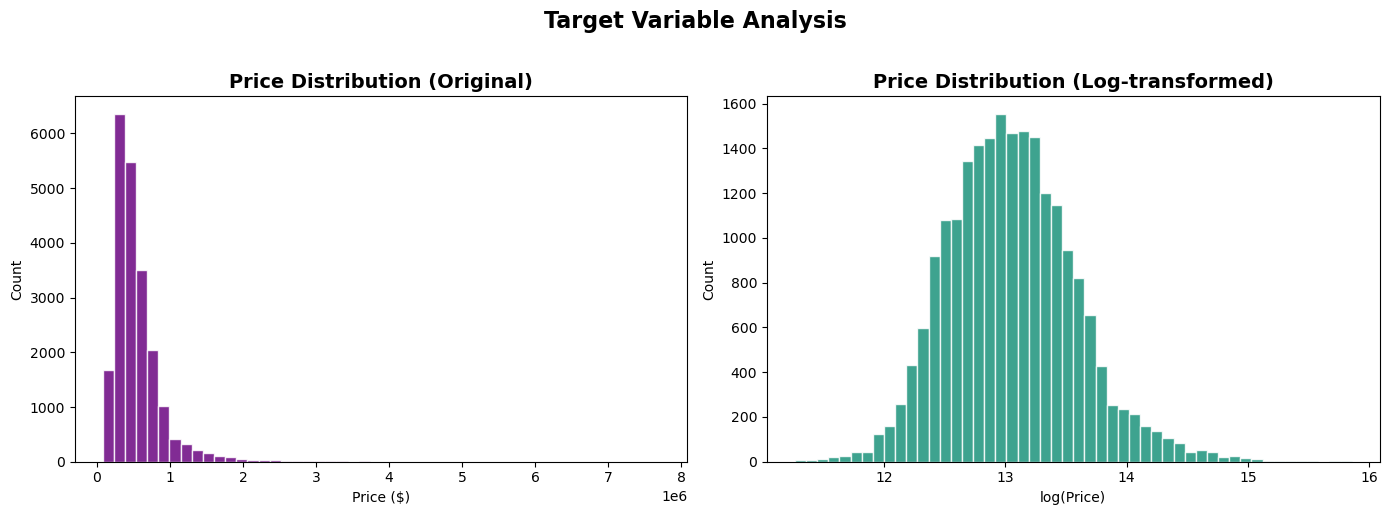

Price skewness (original): 4.026
Price skewness (log): 0.430

Price stats:
  Min:    $78,000
  Median: $450,000
  Mean:   $540,198
  Max:    $7,700,000


In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, color="#6B0682", edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (Original)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['price']), bins=50, color="#1C937B", edgecolor='white', alpha=0.85)
axes[1].set_title('Price Distribution (Log-transformed)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Price skewness (original): {df['price'].skew():.3f}")
print(f"Price skewness (log): {np.log1p(df['price']).skew():.3f}")
print(f"\nPrice stats:")
print(f"  Min:    ${df['price'].min():,.0f}")
print(f"  Median: ${df['price'].median():,.0f}")
print(f"  Mean:   ${df['price'].mean():,.0f}")
print(f"  Max:    ${df['price'].max():,.0f}")

# Consideration: log-transform reduces skewness significantly
# We'll use log(price) as target for linear models

**Correlations**

CORRELATION WITH PRICE
sqft_living      0.701921
grade            0.667935
sqft_above       0.605395
sqft_living15    0.585273
bathrooms        0.525915
view             0.397323
sqft_basement    0.323772
bedrooms         0.315966
lat              0.306772
waterfront       0.266438
floors           0.256831
yr_renovated     0.126418
sqft_lot         0.089885
sqft_lot15       0.082841
yr_built         0.053995
condition        0.036000
long             0.022103
id              -0.016727
zipcode         -0.053443


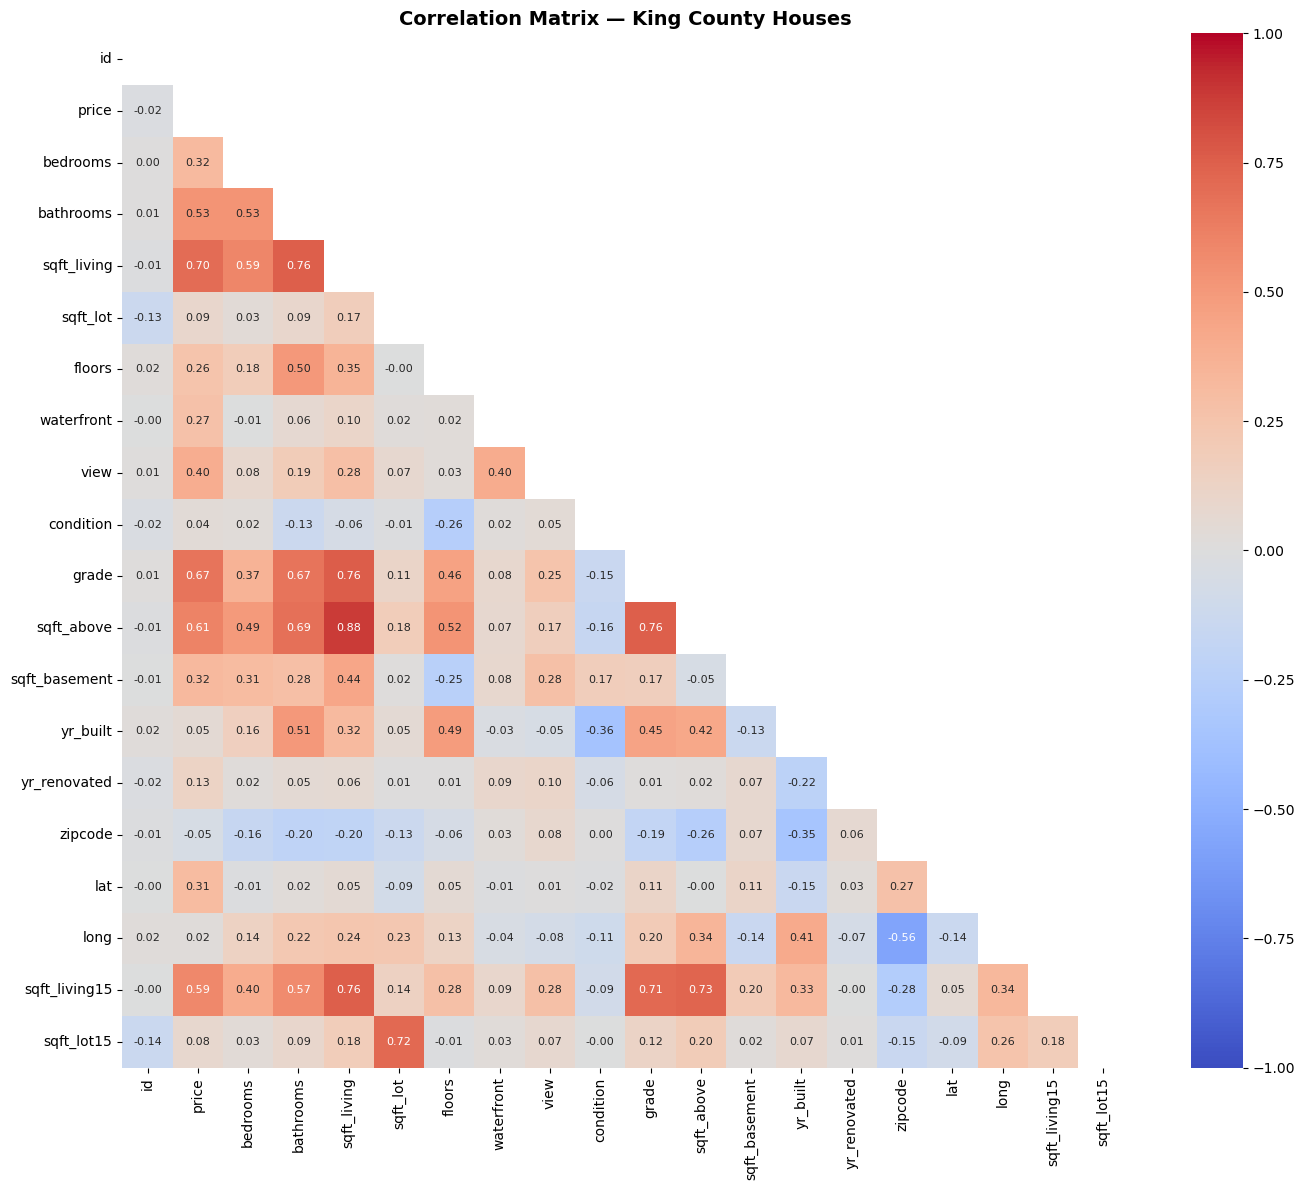


Features with |corr| > 0.3 with price: ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat']


In [91]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

# Correlations with price (sorted)
price_corr = corr['price'].drop('price').sort_values(ascending=False)
print("CORRELATION WITH PRICE")
print(price_corr.to_string())

# Heatmap (lower triangle)
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — King County Houses', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# TOP features by correlation with price
top_features = price_corr[price_corr.abs() > 0.3].index.tolist()
print(f"\nFeatures with |corr| > 0.3 with price: {top_features}")

**Feature Distributions & Outlier Detection**

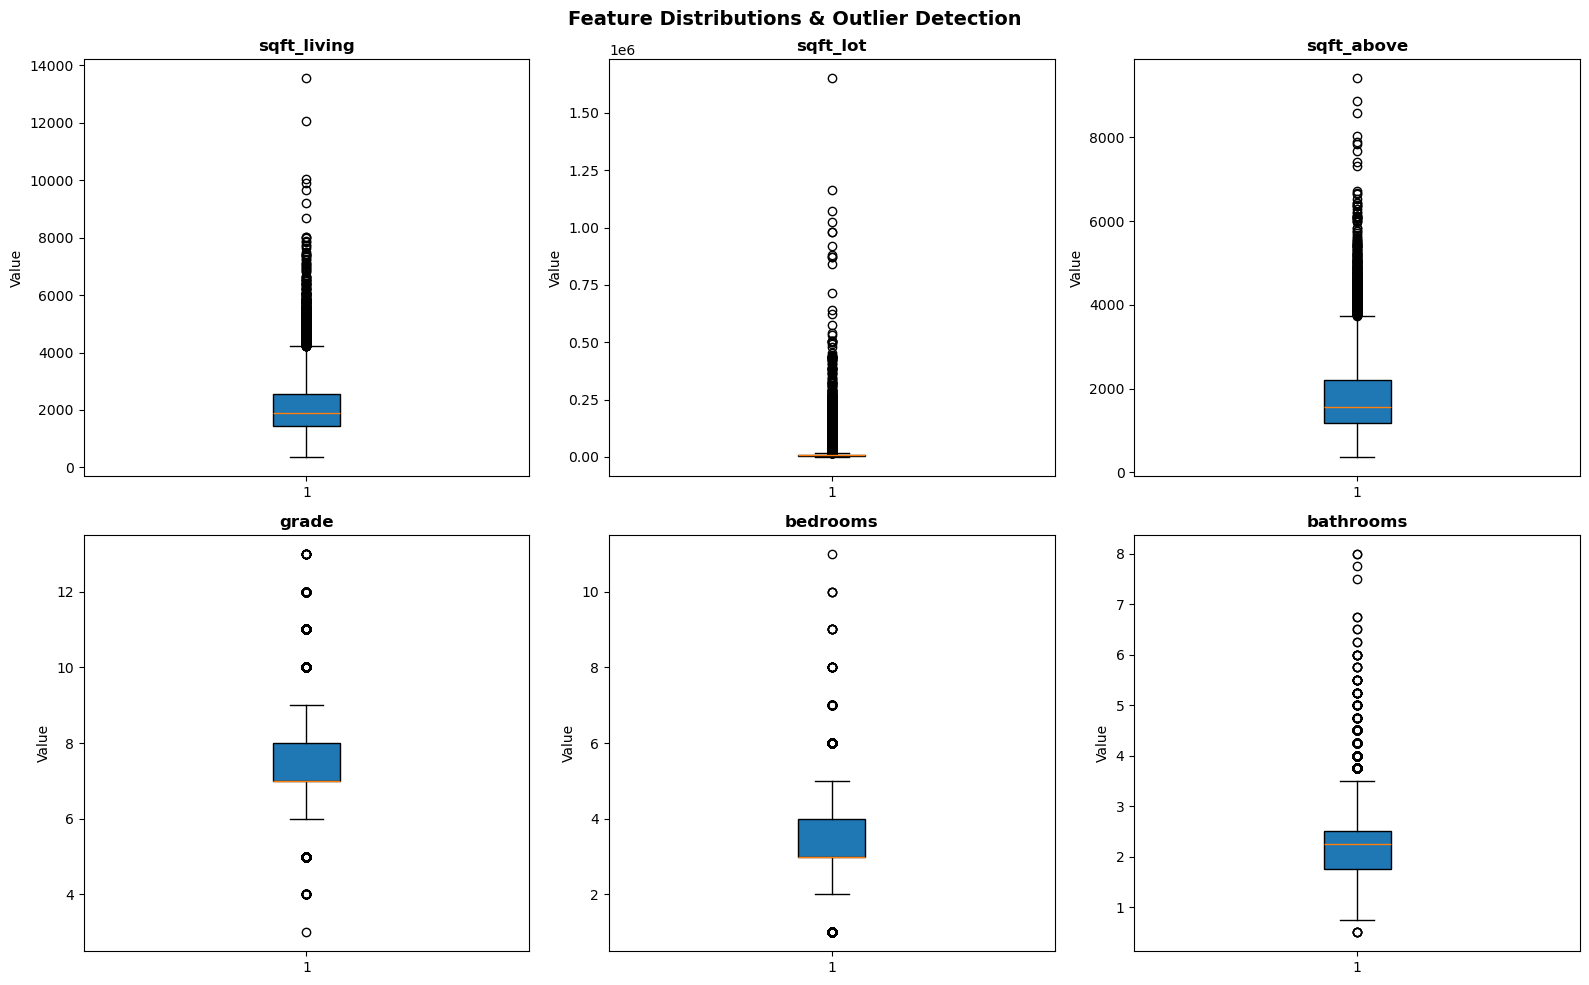

In [92]:
key_features = ['sqft_living', 'sqft_lot', 'sqft_above', 'grade', 'bedrooms', 'bathrooms']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flat, key_features):
    ax.boxplot(df[col].dropna(), patch_artist=True)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')
plt.suptitle('Feature Distributions & Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Price By Key Caterogy**

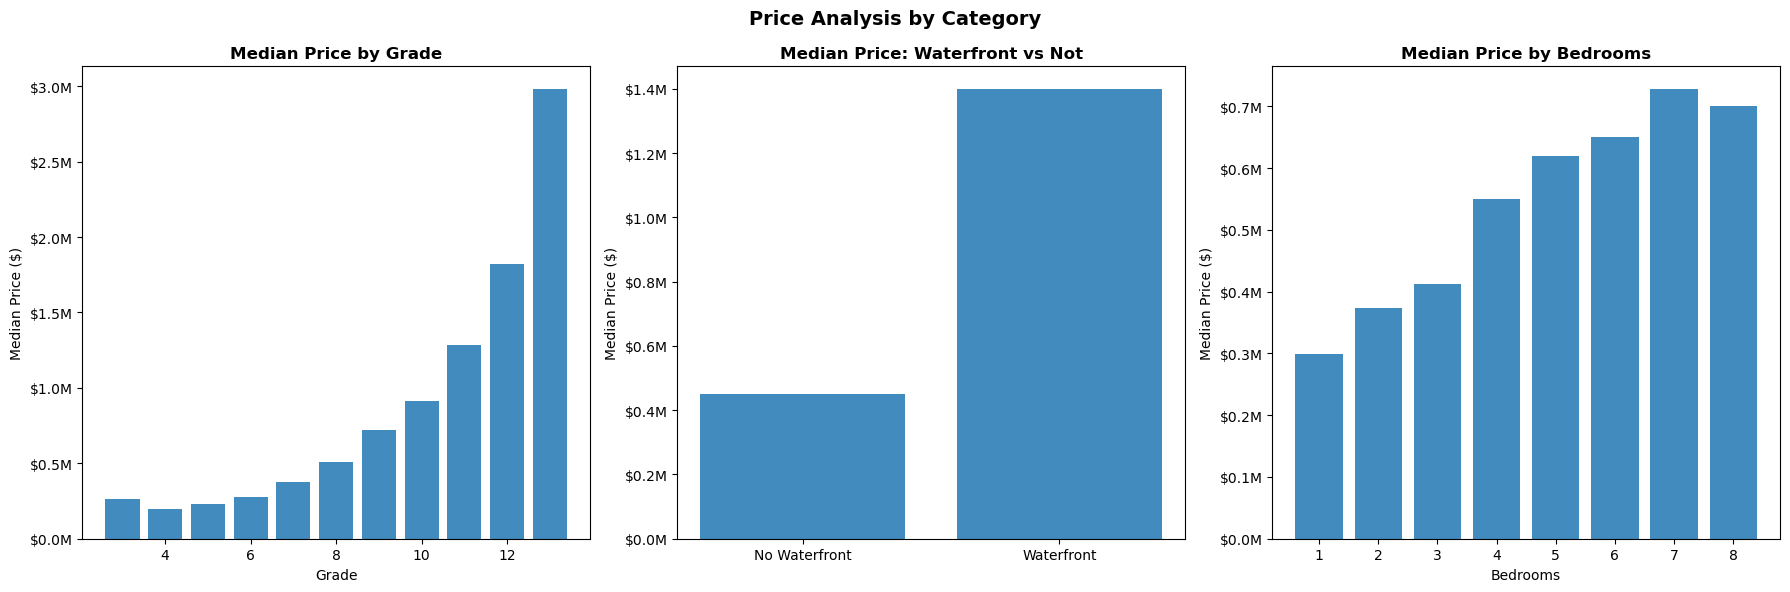

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Grade vs Price
grade_med = df.groupby('grade')['price'].median().reset_index()
axes[0].bar(grade_med['grade'], grade_med['price'], alpha=0.85)
axes[0].set_title('Median Price by Grade', fontweight='bold')
axes[0].set_xlabel('Grade'); axes[0].set_ylabel('Median Price ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Waterfront vs Price
wf_med = df.groupby('waterfront')['price'].median().reset_index()
axes[1].bar(['No Waterfront', 'Waterfront'], wf_med['price'], alpha=0.85)
axes[1].set_title('Median Price: Waterfront vs Not', fontweight='bold')
axes[1].set_ylabel('Median Price ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# Bedrooms vs Price
bed_med = df.groupby('bedrooms')['price'].median().reset_index()
bed_med = bed_med[bed_med['bedrooms'] <= 8]  # Remove extreme outliers
axes[2].bar(bed_med['bedrooms'], bed_med['price'], alpha=0.85)
axes[2].set_title('Median Price by Bedrooms', fontweight='bold')
axes[2].set_xlabel('Bedrooms'); axes[2].set_ylabel('Median Price ($)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle('Price Analysis by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Most Correlated Feature: sqft_living vs Price**

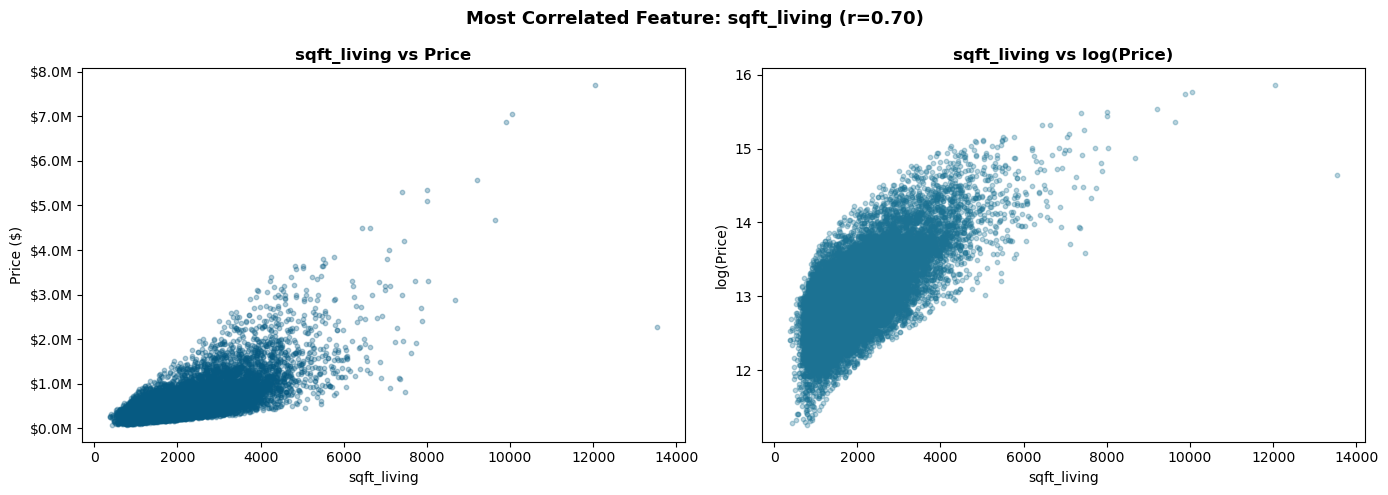

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['sqft_living'], df['price'], alpha=0.3, s=10, color='#065A82')
axes[0].set_xlabel('sqft_living'); axes[0].set_ylabel('Price ($)')
axes[0].set_title('sqft_living vs Price', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

axes[1].scatter(df['sqft_living'], np.log1p(df['price']), alpha=0.3, s=10, color='#1C7293')
axes[1].set_xlabel('sqft_living'); axes[1].set_ylabel('log(Price)')
axes[1].set_title('sqft_living vs log(Price)', fontweight='bold')

plt.suptitle('Most Correlated Feature: sqft_living (r=0.70)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Density Lens (Living Space vs. Lot Size)**

In King County, a small house on a massive lot might be worth more than a huge house on a tiny lot because of land value.

The Goal: See if "High Value" ($650K+) homes are expensive because of the house size or the land size.

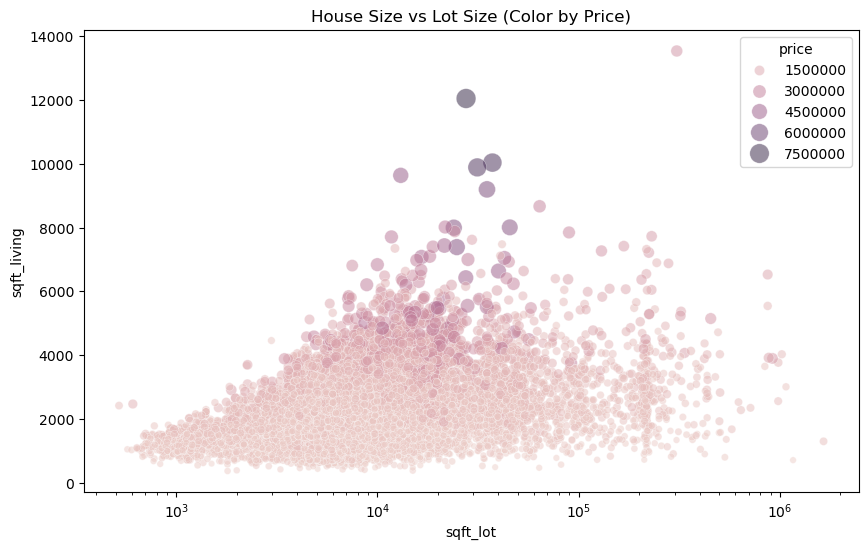

In [ ]:
# Creating a 'Lot Utilization' ratio
df['lot_utilization'] = df['sqft_living'] / df['sqft_lot']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sqft_lot', y='sqft_living', hue='price', size='price', sizes=(20, 200), alpha=0.5)
plt.xscale('log') # Lot sizes vary wildly, so log scale helps see patterns
plt.title('House Size vs Lot Size (Color by Price)')
plt.show()

# The Y-Axis (sqft_living): This is the "Product." It measures how much indoor space you are buying.
# The X-Axis (sqft_lot - Log Scale): This is the "Foundation." 
# Color & Size (price): The darker, larger bubbles represent the $650K+ segment. Notice how they cluster toward the top.

- The Y-Axis (sqft_living): This is the "Product." It measures how much indoor space you are buying.
- The X-Axis (sqft_lot in Log Scale): This is the Foundation. 
- Color & Size (price): The darker, larger bubbles represent the $650K+ segment. **They cluster towards the top**.

**Price By Location**

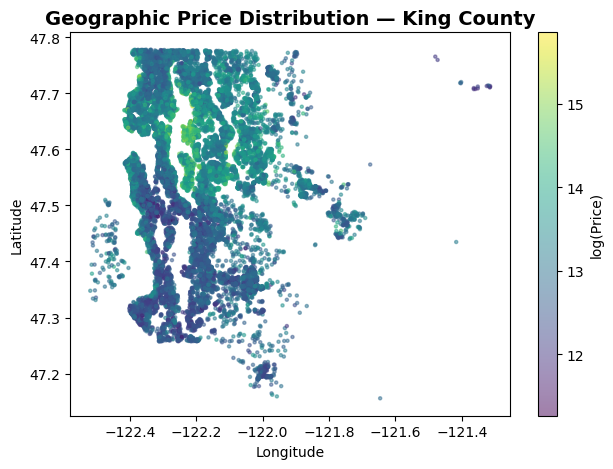

In [112]:
fig, ax = plt.subplots()
scatter = ax.scatter(df['long'], df['lat'],c=np.log1p(df['price']),s=5, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='log(Price)')
ax.set_title('Geographic Price Distribution — King County', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

**Luxury vs Standard comparison**

In [113]:
luxury = df[df['price'] >= 650_000].copy()
standard = df[df['price'] < 650_000].copy()

print(f"Total houses: {len(df):,}")
print(f"Houses ≥ $650K: {len(luxury):,} ({len(luxury)/len(df):.1%})")
print(f"Houses < $650K: {len(standard):,} ({len(standard)/len(df):.1%})")

Total houses: 21,596
Houses ≥ $650K: 5,322 (24.6%)
Houses < $650K: 16,274 (75.4%)


In [114]:
luxury[['price', 'sqft_living', 'bedrooms', 'bathrooms', 'grade', 'waterfront']].describe()

,price,sqft_living,bedrooms,bathrooms,grade,waterfront
count,5.322000e+03,5322.000000,5322.000000,5322.000000,5322.000000,5322.000000
mean,9.905850e+05,3004.845547,3.825442,2.677612,8.848177,0.025179
std,4.778147e+05,1028.541268,0.894011,0.791125,1.226572,0.156682
min,6.500000e+05,890.000000,1.000000,0.750000,5.000000,0.000000
25%,7.250000e+05,2330.000000,3.000000,2.250000,8.000000,0.000000
50%,8.300000e+05,2890.000000,4.000000,2.500000,9.000000,0.000000
75%,1.050000e+06,3510.000000,4.000000,3.250000,10.000000,0.000000
max,7.700000e+06,13540.000000,10.000000,8.000000,13.000000,1.000000


In [115]:
standard[['price', 'sqft_living', 'bedrooms', 'bathrooms', 'grade', 'waterfront']].describe()

,price,sqft_living,bedrooms,bathrooms,grade,waterfront
count,16274.000000,16274.000000,16274.000000,16274.000000,16274.000000,16274.000000
mean,392910.729323,1778.008050,3.223485,1.932131,7.268711,0.001782
std,127233.415553,633.858236,0.856803,0.665691,0.848433,0.042177
min,78000.000000,370.000000,1.000000,0.500000,3.000000,0.000000
25%,290000.000000,1310.000000,3.000000,1.500000,7.000000,0.000000
50%,385000.000000,1700.000000,3.000000,2.000000,7.000000,0.000000
75%,494998.750000,2160.000000,4.000000,2.500000,8.000000,0.000000
max,649990.000000,5461.000000,11.000000,7.500000,11.000000,1.000000


In [116]:
# Luxury vs Standard comparison
compare_cols = ['sqft_living', 'grade', 'bathrooms', 'view', 'waterfront']
comparison = pd.DataFrame({'Standard (<$650K)': standard[compare_cols].mean(),'Luxury (≥$650K)': luxury[compare_cols].mean()}).round(2)
comparison

,Standard (<$650K),Luxury (≥$650K)
sqft_living,1778.01,3004.85
grade,7.27,8.85
bathrooms,1.93,2.68
view,0.11,0.63
waterfront,0.00,0.03


# **Feature Engineering**

Based on the columns description:
- **id**: Doesn't store relevant data, can be dropped.
- **date**: can be converted to datetime for feature extraction.
- **lat**: Dropped, as is way too specific. Also, location is stored at zipcode which is more general.
- **long**: Dropped, as is way too specific. Also, location is stored at zipcode which is more general.

Relevant information added:
- **house_age**: defined as sale_year - yr_built
- **was_renovated**: flag renovated properties
- **year_since_reno**: when renovated, sale_year - yr_renovated
- **price_per_sqft**: price / sqft_living (EDA purposes)
- **has_basement**: flag properties with basement
- **living_vs_neighboors**: (Neighbor size ratio)

In [117]:
df_eng = df.copy()

# Date
df_eng['date'] = pd.to_datetime(df_eng['date'])
df_eng['sale_year']  = df_eng['date'].dt.year
df_eng['sale_month'] = df_eng['date'].dt.month

# House age at time of sale
df_eng['house_age'] = df_eng['sale_year'] - df_eng['yr_built']

# Was it renovated?
df_eng['was_renovated'] = (df_eng['yr_renovated'] > 0).astype(int)

# Years since renovation (if renovated)
df_eng['years_since_reno'] = np.where(df_eng['yr_renovated'] > 0,
    df_eng['sale_year'] - df_eng['yr_renovated'],df_eng['house_age'])

# Price per sqft (for EDA only — don't use as feature to predict price)
df_eng['price_per_sqft'] = df_eng['price'] / df_eng['sqft_living']

# Basement flag
df_eng['has_basement'] = (df_eng['sqft_basement'] > 0).astype(int)

# Neighbor size ratio
df_eng['living_vs_neighbors'] = df_eng['sqft_living'] / (df_eng['sqft_living15'] + 1)

# New Features:
new_cols = ['sale_year', 'sale_month', 'house_age', 'was_renovated','years_since_reno', 'has_basement', 'living_vs_neighbors']
df_eng[new_cols].describe().round(2)

,sale_year,sale_month,house_age,was_renovated,years_since_reno,has_basement,living_vs_neighbors
count,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00
mean,2014.32,6.57,43.32,0.04,40.94,0.39,1.05
std,0.47,3.12,29.38,0.20,28.82,0.49,0.32
min,2014.00,1.00,-1.00,0.00,-1.00,0.00,0.19
25%,2014.00,4.00,18.00,0.00,15.00,0.00,0.88
50%,2014.00,6.00,40.00,0.00,37.00,0.00,1.00
75%,2015.00,9.00,63.00,0.00,60.00,1.00,1.16
max,2015.00,12.00,115.00,1.00,115.00,1.00,5.99


# **Preprocessing**

In [118]:
# Features to use
feature_cols = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement',
                'bedrooms', 'bathrooms', 'floors', 'waterfront', 'view',
                'condition', 'grade', 'house_age', 'was_renovated',
                'years_since_reno', 'has_basement', 'living_vs_neighbors',
                'sale_month', 'sqft_living15', 'sqft_lot15']

# Log-transform target (reduces skewness from 4.0 -> 0.4)
df_eng['log_price'] = np.log1p(df_eng['price'])

X = df_eng[feature_cols]
y = df_eng['log_price']

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Features: {len(feature_cols)}")

Train size: (17276, 19)
Test size: (4320, 19)
Features: 19


# **Model Training & Comparison**

In [119]:
models = {  'Linear Regression': LinearRegression(),
            'Ridge': Ridge(alpha=1.0),
            'Lasso': Lasso(alpha=0.001),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),}

results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred_log = model.predict(X_test_sc)
    # Back-transform from log space
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    print(f"{name:<25}  RMSE: ${rmse:,.0f}  MAE: ${mae:,.0f}  R²: {r2:.4f}")

results_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print("\nRANKING BY R²")
print(results_df.round(4))


Linear Regression          RMSE: $196,941  MAE: $129,944  R²: 0.7037
Ridge                      RMSE: $196,930  MAE: $129,942  R²: 0.7037
Lasso                      RMSE: $196,553  MAE: $129,807  R²: 0.7048
Random Forest              RMSE: $189,096  MAE: $114,498  R²: 0.7268
Gradient Boosting          RMSE: $184,198  MAE: $119,308  R²: 0.7408

RANKING BY R²
                          RMSE          MAE      R²
Gradient Boosting  184197.6656  119308.4040  0.7408
Random Forest      189095.7640  114498.3625  0.7268
Lasso              196552.9697  129806.9849  0.7048
Ridge              196930.4049  129941.8991  0.7037
Linear Regression  196940.6601  129943.8718  0.7037


By comparing results, the best model is Gradient Boosting:

In [120]:
best_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train_sc, y_train)

y_pred = np.expm1(best_model.predict(X_test_sc))
y_true = np.expm1(y_test)

rmse_final = np.sqrt(mean_squared_error(y_true, y_pred))
mae_final  = mean_absolute_error(y_true, y_pred)
r2_final   = r2_score(y_true, y_pred)

print(f"RMSE: ${rmse_final:,.0f}")
print(f"MAE:  ${mae_final:,.0f}")
print(f"R²:   {r2_final:.4f}")

RMSE: $184,198
MAE:  $119,308
R²:   0.7408


**Feature Relevance**

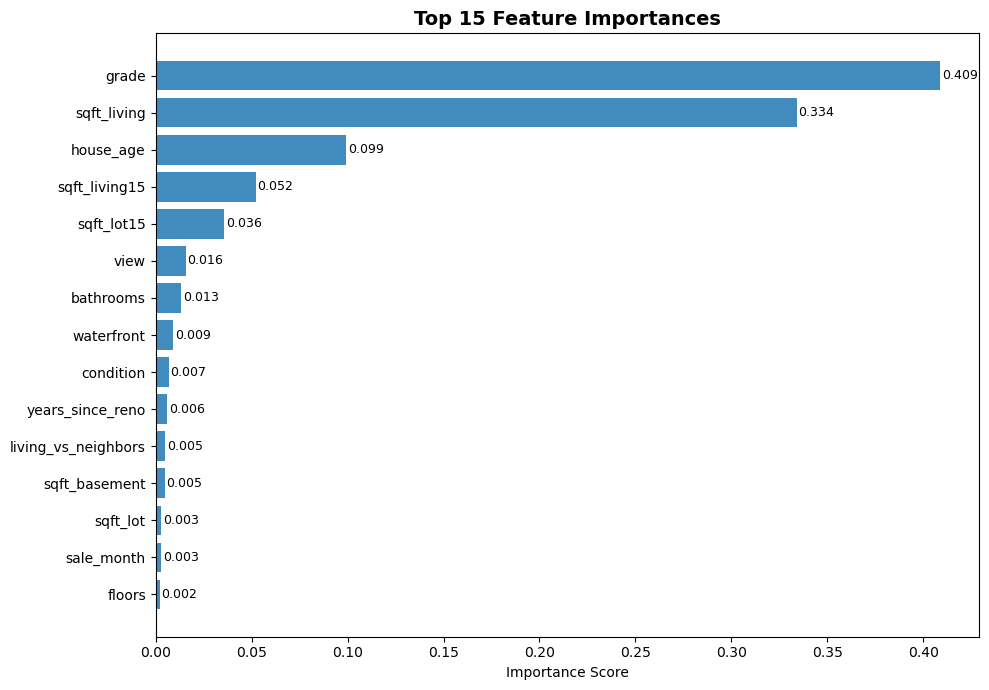

In [121]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importances.index, importances.values, alpha=0.85)
ax.set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


# **Predicted x Actual Prices (Visualizations)**

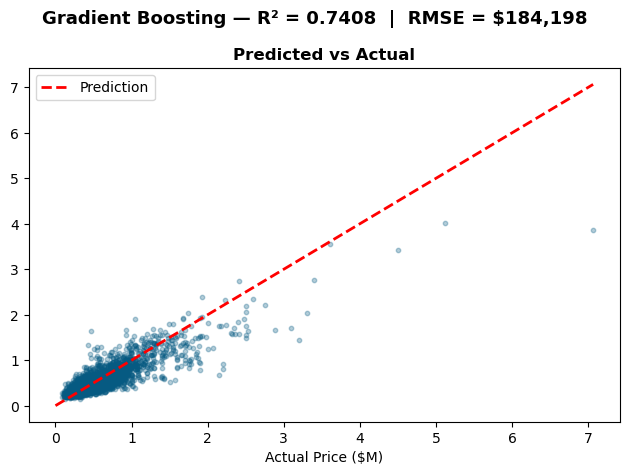

In [122]:
# Predicted x Actual
plt.scatter(y_true/1e6, y_pred/1e6, alpha=0.3, s=10, color='#065A82')
max_val = max(y_true.max(), y_pred.max()) / 1e6
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Prediction')
plt.xlabel('Actual Price ($M)'); axes[0].set_ylabel('Predicted Price ($M)')
plt.title('Predicted vs Actual', fontweight='bold')
plt.legend()
plt.suptitle(f'Gradient Boosting — R² = {r2_final:.4f}  |  RMSE = ${rmse_final:,.0f}',fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Scope: Luxery Segment**

LUXURY SEGMENT PERFORMANCE (≥$650K)
N houses: 1,025
RMSE: $313,633
R²: 0.5631


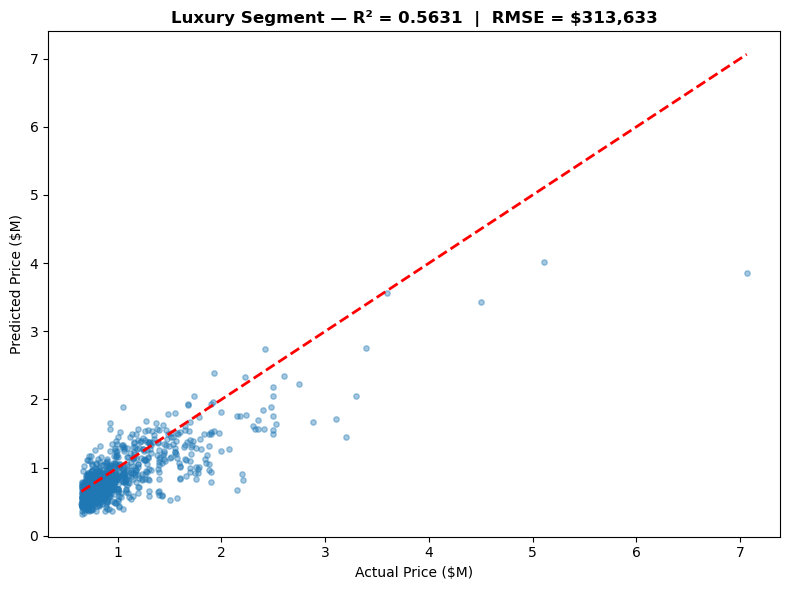

In [123]:
luxury_mask = y_true >= 650_000
y_true_lux = y_true[luxury_mask]
y_pred_lux = y_pred[luxury_mask]

r2_lux = r2_score(y_true_lux, y_pred_lux)
rmse_lux = np.sqrt(mean_squared_error(y_true_lux, y_pred_lux))

print(f"LUXURY SEGMENT PERFORMANCE (≥$650K)")
print(f"N houses: {luxury_mask.sum():,}")
print(f"RMSE: ${rmse_lux:,.0f}")
print(f"R²: {r2_lux:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_true_lux/1e6, y_pred_lux/1e6, alpha=0.4, s=15)
max_val = max(y_true_lux.max(), y_pred_lux.max()) / 1e6
ax.plot([0.65, max_val], [0.65, max_val], 'r--', linewidth=2)
ax.set_xlabel('Actual Price ($M)'); ax.set_ylabel('Predicted Price ($M)')
ax.set_title(f'Luxury Segment — R² = {r2_lux:.4f}  |  RMSE = ${rmse_lux:,.0f}',fontweight='bold')
plt.tight_layout()
plt.show()